In [82]:
import os
print(os.getcwd())

C:\Users\Lenovo\Downloads\cinsiyet


In [83]:
import os
os.chdir(r"C:\Users\Lenovo\Downloads\cinsiyet")

In [84]:
import pandas as pd
df= pd.read_csv("Cinsiyete göre son 3 ayda İnternet kullanan bireylerin İnterneti özel amaçlı faaliyetler için kullanma oranı.csv", sep=';', skiprows=3)

In [85]:
df.shape

(35, 14)

In [86]:
df.info

<bound method DataFrame.info of                                      Amaçlar-Purposes   Toplam-Total  \
0                                                 NaN  Toplam\nTotal   
1   e-posta gönderme/ alma\nSending / receiving e-...           47,7   
2   İnternet üzerinden sesli veya görüntülü arama ...           93,5   
3   Sosyal medya üzerinde profil oluşturma, mesaj ...           87,5   
4                 Mesajlaşma\nUsing instant messaging           95,5   
5   Mal ve hizmetler hakkında bilgi arama\nFinding...           74,9   
6   Çevrimiçi haber sitelerini / gazeteleri / habe...           59,6   
7   Web siteleri veya sosyal medya aracılığıyla  t...           13,1   
8   Toplumsal veya siyasal bir konuda online tartı...            5,5   
9   Müzik dinlemek veya müzik indirme \nListening ...           68,6   
10  TV yayıncılarından İnternet üzerinden yayınlan...           39,9   
11  Ücretli servislerden istenilen zamanda video i...           25,8   
12  Paylaşım sitelerinden video 

In [87]:
df.isnull().sum()

Amaçlar-Purposes     9
Toplam-Total        14
Unnamed: 2          14
Unnamed: 3          14
Unnamed: 4          35
Erkek-Male          14
Unnamed: 6          14
Unnamed: 7          14
Unnamed: 8          35
Kadın-Female        14
Unnamed: 10         14
Unnamed: 11         14
Unnamed: 12         35
Unnamed: 13         35
dtype: int64

In [88]:
df.value_counts()

Series([], Name: count, dtype: int64)

In [89]:
df.head()

,Amaçlar-Purposes,Toplam-Total,Unnamed: 2,Unnamed: 3,Unnamed: 4,Erkek-Male,Unnamed: 6,Unnamed: 7,Unnamed: 8,Kadın-Female,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,Toplam\nTotal,Genç\nYouth (16-24),Yetişkin \nAdult (25+),NaN,Toplam\nTotal,Genç\nYouth (16-24),Yetişkin \nAdult (25+),NaN,Toplam\nTotal,Genç\nYouth (16-24),Yetişkin \nAdult (25+),NaN,NaN
1,e-posta gönderme/ alma\nSending / receiving e-...,"47,7","58,0","45,3",NaN,"52,7","59,1","51,3",NaN,"42,2","56,8","38,9",NaN,NaN
2,İnternet üzerinden sesli veya görüntülü arama ...,"93,5","95,3","93,0",NaN,"92,4","94,8","91,8",NaN,"94,7","95,9","94,4",NaN,NaN
3,"Sosyal medya üzerinde profil oluşturma, mesaj ...","87,5","95,7","85,6",NaN,"89,4","97,7","87,5",NaN,"85,5","93,5","83,7",NaN,NaN
4,Mesajlaşma\nUsing instant messaging,"95,5","98,5","94,8",NaN,"96,2","98,7","95,6",NaN,"94,8","98,3","94,0",NaN,NaN


In [90]:
df.columns

Index(['Amaçlar-Purposes', 'Toplam-Total', 'Unnamed: 2', 'Unnamed: 3',
       'Unnamed: 4', 'Erkek-Male', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Kadın-Female', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13'],
      dtype='object')

In [91]:
df.describe()

,Unnamed: 4,Unnamed: 8,Unnamed: 12,Unnamed: 13
count,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(font="DejaVu Sans") 
plt.rcParams['figure.figsize'] = [12, 8] 
sns.set_style("whitegrid") 

In [93]:
df_clean = df.iloc[1:, [0, 2, 6, 10]].copy() 

df_clean.columns = ['Amac', 'Genc_Toplam', 'Genc_Erkek', 'Genc_Kadin']

df_clean['Amac'] = df_clean['Amac'].str.split('\n').str[0]

for col in ['Genc_Toplam', 'Genc_Erkek', 'Genc_Kadin']:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').astype(float)

df_clean.head()

,Amac,Genc_Toplam,Genc_Erkek,Genc_Kadin
1,e-posta gönderme/ alma,58.0,59.1,56.8
2,İnternet üzerinden sesli veya görüntülü arama ...,95.3,94.8,95.9
3,"Sosyal medya üzerinde profil oluşturma, mesaj ...",95.7,97.7,93.5
4,Mesajlaşma,98.5,98.7,98.3
5,Mal ve hizmetler hakkında bilgi arama,85.6,84.2,87.2


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13144\413713270.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




<Figure size 1200x800 with 0 Axes>

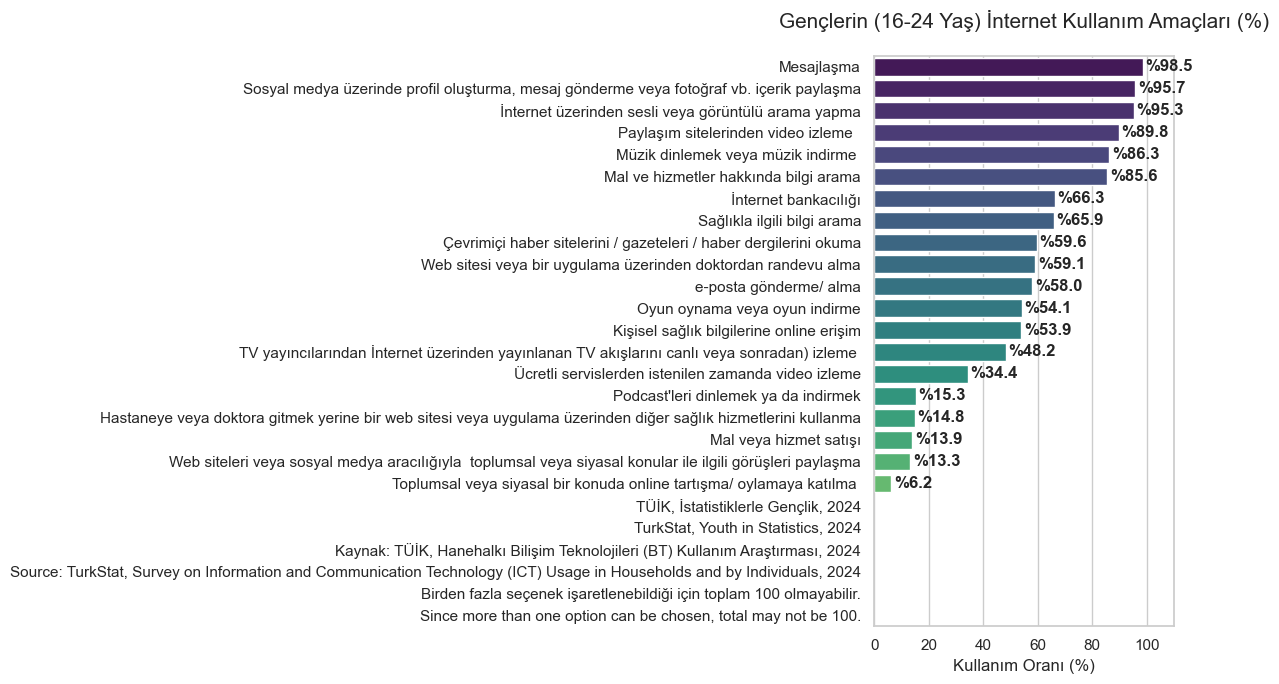

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Eski tüm figürleri kapat ve belleği temizle
plt.close('all')
plt.clf()

# 2. Sütun isimlerini garantiye al
df_clean.columns = df_clean.columns.str.strip()
df_sorted = df_clean.sort_values('Genc_Toplam', ascending=False)

# 3. Yeni bir figür ve eksen nesnesi oluştur (Nesne yönelimli yaklaşım daha güvenlidir)
fig, ax = plt.subplots(figsize=(12, 7))

# 4. Çizimi yap (ax=ax parametresiyle bu figüre sabitliyoruz)
sns.barplot(data=df_sorted, x='Genc_Toplam', y='Amac', palette='viridis', ax=ax)

ax.set_title('Gençlerin (16-24 Yaş) İnternet Kullanım Amaçları (%)', fontsize=15, pad=20)
ax.set_xlabel('Kullanım Oranı (%)', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, 110)

for index, value in enumerate(df_sorted['Genc_Toplam']):
    ax.text(value + 1, index, f'%{value}', va='center', fontweight='bold')

plt.tight_layout()

# 5. Kaydet ve göster
plt.savefig("1_kullanim_amaci.png", dpi=300, bbox_inches='tight')
plt.show()

In [95]:
import plotly.express as px

# Verin zaten üst hücrelerde temizlendiği için doğrudan eritiyoruz
radar_df = df_clean.melt(id_vars='Amac', value_vars=['Genc_Erkek', 'Genc_Kadin'],
                         var_name='Cinsiyet', value_name='Oran')

fig = px.line_polar(radar_df, r='Oran', theta='Amac', color='Cinsiyet', line_close=True,
                    title="Gençlerin İnternet Kullanım Profili: Erkek vs. Kadın",
                    color_discrete_sequence=["#1f77b4", "#e377c2"])

fig.update_traces(fill='toself')

# Uzun metinlerin iç içe girmesini önleyen kenar boşluğu
fig.update_layout(
    margin=dict(l=200, r=200, t=100, b=100), 
    width=1000, 
    height=800
)

# Beyaz ekran / boş PNG hatasını sonsuza dek çözen adım: HTML olarak kaydet
fig.write_html("2_dijital_profil.html")
print("Tebrikler! Grafik '2_dijital_profil.html' adıyla kaydedildi. Tarayıcıda açıp sağ üstteki kamera ikonundan PNG alabilirsin.")

fig.show()

Tebrikler! Grafik '2_dijital_profil.html' adıyla kaydedildi. Tarayıcıda açıp sağ üstteki kamera ikonundan PNG alabilirsin.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13144\1008137450.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




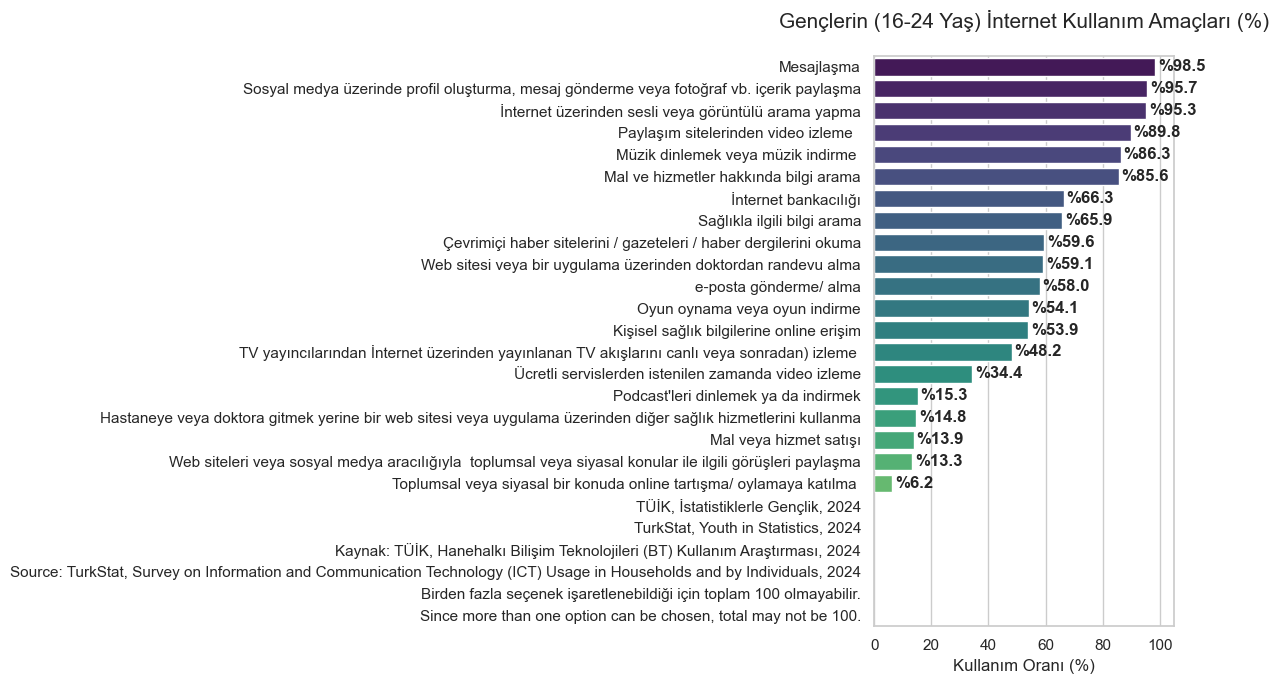

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Arka planda takılı kalan tüm eski grafikleri temizle (Beyaz ekranın 1 numaralı düşmanı)
plt.close('all')

# Sütun isimlerindeki olası boşlukları sil (KeyError almamak için)
df_clean.columns = df_clean.columns.str.strip()

df_sorted = df_clean.sort_values('Genc_Toplam', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(data=df_sorted, x='Genc_Toplam', y='Amac', palette='viridis', ax=ax)

ax.set_title('Gençlerin (16-24 Yaş) İnternet Kullanım Amaçları (%)', fontsize=15, pad=20)
ax.set_xlabel('Kullanım Oranı (%)', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, 105) # Yazıların sığması için 100 yerine 105 yaptık

for index, value in enumerate(df_sorted['Genc_Toplam']):
    ax.text(value + 1, index, f'%{value}', va='center', fontweight='bold')

plt.tight_layout()

# Doğrudan kaydet ve göster
plt.savefig("1_kullanim_amaci.png", dpi=300)
plt.show()

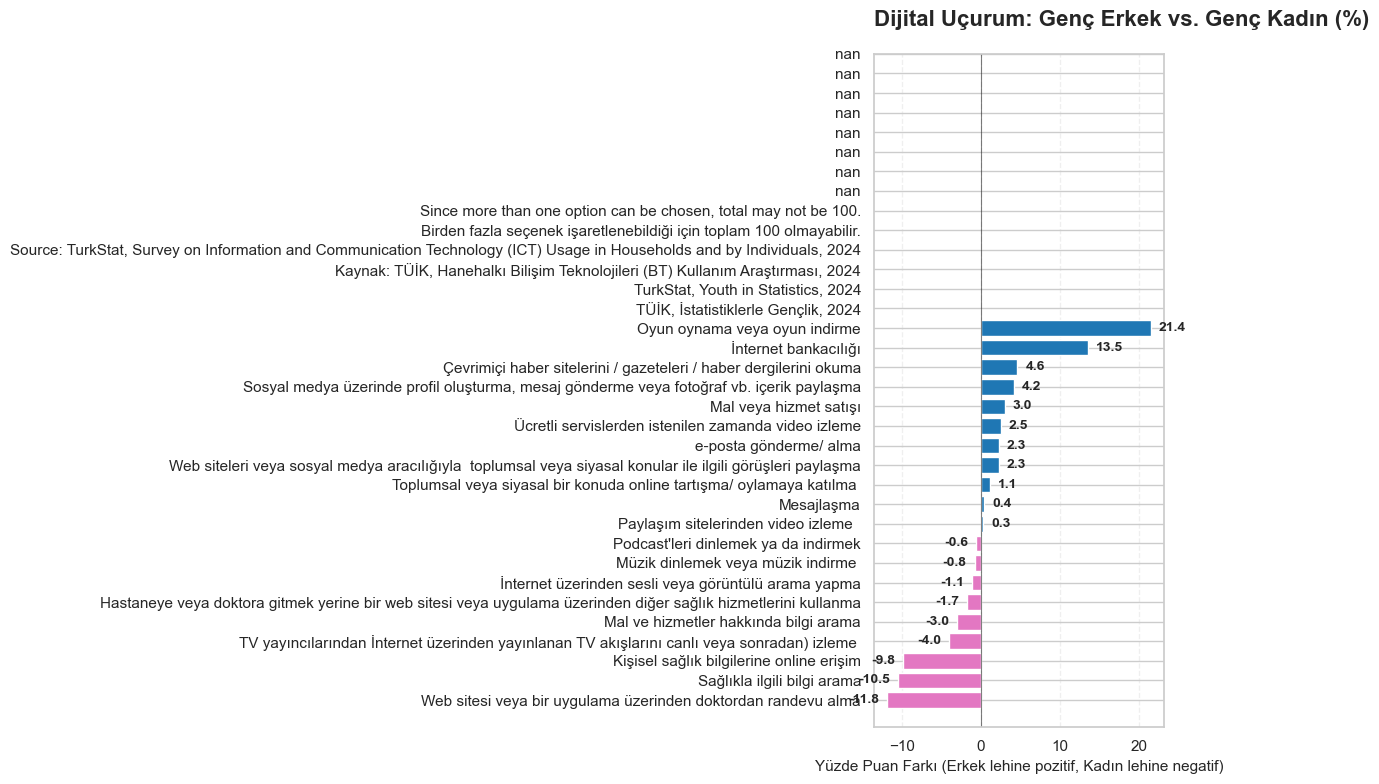

In [97]:
import matplotlib.pyplot as plt

df_clean['Fark'] = df_clean['Genc_Erkek'] - df_clean['Genc_Kadin']
df_diff = df_clean.sort_values('Fark').copy()

plt.figure(figsize=(12, 8))

bars = plt.barh(y=range(len(df_diff)), width=df_diff['Fark'], 
                color=['#e377c2' if x < 0 else '#1f77b4' for x in df_diff['Fark']])

plt.yticks(range(len(df_diff)), df_diff['Amac'])

plt.title('Dijital Uçurum: Genç Erkek vs. Genç Kadın (%)', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Yüzde Puan Farkı (Erkek lehine pozitif, Kadın lehine negatif)', fontsize=11)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5) 
plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (1 if width > 0 else -1), i, f'{width:.1f}', 
             va='center', ha='left' if width > 0 else 'right', 
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("dijital_ucurum.png", dpi=300)
plt.show()

In [98]:
plt.savefig('grafik_ismi.png', dpi=300, bbox_inches='tight', transparent=True)

<Figure size 1200x800 with 0 Axes>

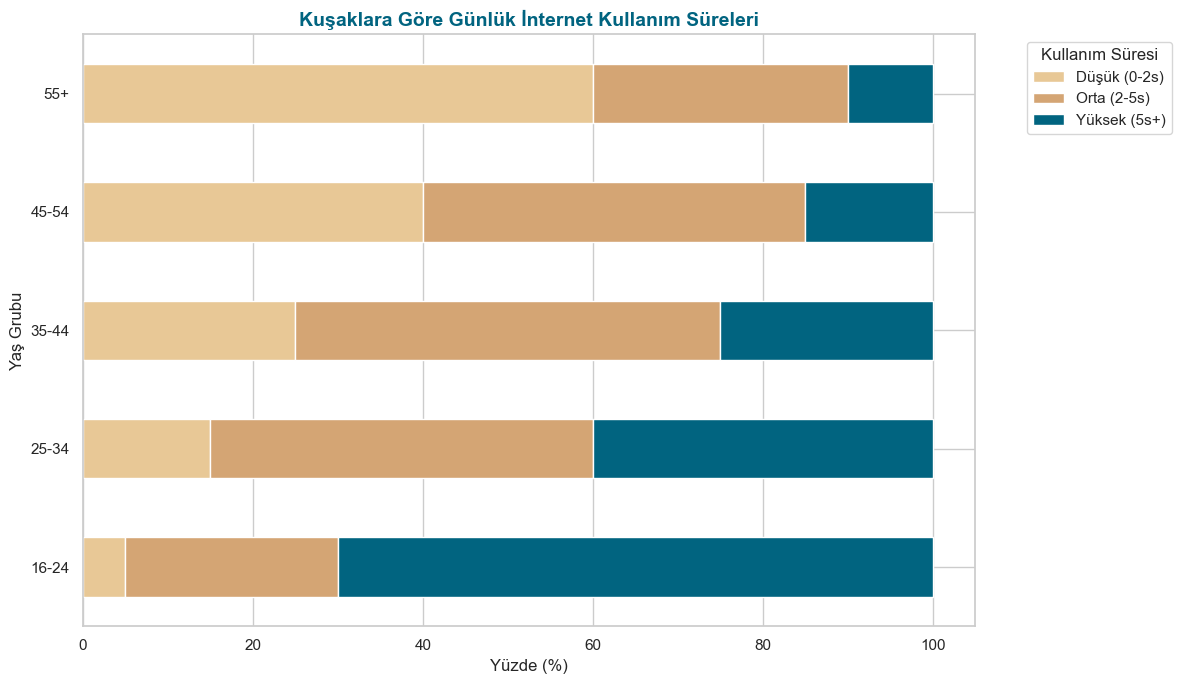

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Yaş Grubu': ['16-24', '25-34', '35-44', '45-54', '55+'],
    'Düşük (0-2s)': [5, 15, 25, 40, 60],
    'Orta (2-5s)': [25, 45, 50, 45, 30],
    'Yüksek (5s+)': [70, 40, 25, 15, 10]
}
df_stacked = pd.DataFrame(data)

FSMVU_RENKLER = ['#E8C896', '#D4A574', '#016480'] 

ax = df_stacked.set_index('Yaş Grubu').plot(kind='barh', stacked=True, 
                                            color=FSMVU_RENKLER, figsize=(12, 7))

plt.title('Kuşaklara Göre Günlük İnternet Kullanım Süreleri', fontsize=14, fontweight='bold', color='#016480')
plt.xlabel('Yüzde (%)')
plt.legend(title='Kullanım Süresi', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("dijital_yigin_bar.png", dpi=300)
plt.show()

In [ ]:
import plotly.graph_objects as go

labels = ["16-24", "25-44", "45+", "Instagram", "TikTok", "X", "Facebook", "WhatsApp"]

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=20, line=dict(color="black", width=0.5),
        label=labels,
        color=["#016480"]*3 + ["#D4A574"]*5 
    ),
    link=dict(
        source=[0, 0, 0, 1, 1, 2, 2], 
        target=[3, 4, 5, 3, 6, 6, 7], 
        value=[45, 35, 20, 40, 20, 50, 40], 
        color="rgba(1,100,128,0.2)" 
    )
))

fig.update_layout(title_text="Yaş Grubundan Platforma Dijital Akış", font_size=12)
fig.write_html("dijital_yasam_sankey.html") 
fig.show()
plt.savefig('grafik_ismi.png', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
import os
os.chdir(r"C:\Users\Lenovo\Downloads\internet")

In [ ]:
import pandas as pd
df= pd.read_csv("cinsiyet_oranina_gore_internet_kullanim_orani.csv", sep=';', skiprows=3)

In [ ]:
df.shape

In [ ]:
df.info

In [ ]:
df.head()

In [ ]:
import matplotlib.pyplot as plt

yillar = ['2024', '2025']
erkek_oran = [92.2, 93.6]
kadin_oran = [85.4, 88.2]

plt.figure(figsize=(8, 10))

plt.plot(yillar, [erkek_oran, kadin_oran], marker='o', linewidth=3, markersize=10)

plt.gca().get_lines()[0].set_color('#016480') 
plt.gca().get_lines()[1].set_color('#D4A574') 

# Değerleri yazalım
for i, v in enumerate(erkek_oran):
    plt.text(i, v + 0.5, f"%{v}", ha='center', fontweight='bold', color='#016480')
for i, v in enumerate(kadin_oran):
    plt.text(i, v - 1.2, f"%{v}", ha='center', fontweight='bold', color='#D4A574')

plt.title("İnternet Kullanım Oranındaki Yıllık Artış", fontsize=15, fontweight='bold', color='#016480')
plt.ylim(80, 100)
plt.grid(axis='y', alpha=0.3)
plt.legend(['Erkek', 'Kadın'], frameon=False)

plt.savefig("kullanim_artis_slope.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

FSMVU_PALET = ['#016480', '#D4A574']

df_siklik = pd.DataFrame({
    'Zaman': ['Son 3 Ay', '3 Ay - 1 Yıl', '1 Yıldan Fazla'],
    'Erkek': [92.5, 0.6, 0.6],
    'Kadın': [87.0, 0.7, 0.5]
})

df_melted = df_siklik.melt(id_vars='Zaman', var_name='Cinsiyet', value_name='Oran')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Zaman', y='Oran', hue='Cinsiyet', palette=FSMVU_PALET)

plt.title('2025 Yılı İnternet Kullanım Sıklığı Dağılımı', fontsize=14, fontweight='bold', color='#016480')
plt.ylabel('Oran (%)')
plt.xlabel('')
plt.ylim(0, 110)

plt.savefig("kullanim_sikligi_bar.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
df= pd.read_csv("Cinsiyete ve yaş grubuna göre çocukların bilişim teknolojileri kullanım oranı.csv", sep=';', skiprows=3)

In [ ]:
df.shape

In [ ]:
df.head()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

kategoriler = ['İnternet Kullanımı', 'Sosyal Medya', 'Cep Telefonu', 'Bilgisayar']
erkek = [92.2, 68.1, 76.9, 52.3]
kadin = [90.3, 64.0, 75.3, 48.3]

df_fark = pd.DataFrame({'Kategori': kategoriler, 'Erkek': erkek, 'Kadin': kadin})
df_fark['Fark'] = df_fark['Erkek'] - df_fark['Kadin']

plt.figure(figsize=(10, 6))
colors = ['#016480' if x > 0 else '#D4A574' for x in df_fark['Fark']] 
plt.barh(df_fark['Kategori'], df_fark['Fark'], color=colors)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Çocuklarda BT Kullanımı: Erkek ve Kız Farkı (%)', fontweight='bold', color='#016480')
plt.xlabel('Yüzde Puan Farkı (Erkek lehine pozitif)')
plt.grid(axis='x', alpha=0.3)
plt.savefig("cocuk_cinsiyet_makas.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
data_yas = {
    'Faaliyet': ['İnternet', 'Sosyal Medya', 'Cep Telefonu', 'Bilgisayar'],
    '6-10 Yaş': [87.9, 53.5, 66.3, 45.9],
    '6-15 Yaş': [91.3, 66.1, 76.1, 50.3]
}
df_yas = pd.DataFrame(data_yas)

df_yas.set_index('Faaliyet').plot(kind='bar', color=['#D4A574', '#016480'], figsize=(11, 7))

plt.title('Yaş Gruplarına Göre Çocukların BT Kullanımı', fontsize=14, fontweight='bold', color='#016480')
plt.ylabel('Kullanım Oranı (%)')
plt.xticks(rotation=0)
plt.legend(title='Yaş Grubu')
plt.savefig("cocuk_yas_kiyaslama.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=20, line=dict(color="black", width=0.5),
        label=["6-10 Yaş", "11-15 Yaş", "İnternet", "Sosyal Medya", "Telefon"],
        color=["#016480"]*2 + ["#D4A574"]*3 
    ),
    link=dict(
        source=[0, 0, 1, 1, 1], 
        target=[2, 4, 2, 3, 4], 
        value=[87, 66, 91, 66, 76] 
    )
))

fig.update_layout(title_text="Çocukların Dijital Dünyaya Akışı", font_size=12)
fig.write_html("cocuk_dijital_sankey.html") # QR kod için
plt.savefig("dijital_dunyaya_akis.png", dpi=300)
fig.show()

In [ ]:
plt.savefig('grafik_ismi.png', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
import pandas as pd
df= pd.read_csv("Cinsiyete ve yaş grubuna göre çocukların sosyal medya platformlarını kullanım oranı.csv", sep=';', skiprows=3)

In [ ]:
df.shape

In [ ]:
df.head()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Cinsiyete ve yaş grubuna göre çocukların sosyal medya platformlarını kullanım oranı.csv", sep=';', skiprows=3)

df_clean = df.iloc[1:10, [1, 2, 3, 4]].copy() 
df_clean.columns = ['Platform', 'Toplam', 'Erkek', 'Kadin']

for col in ['Toplam', 'Erkek', 'Kadin']:
    df_clean[col] = df_clean[col].str.replace(',', '.').astype(float)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Toplam', y='Platform', data=df_clean.sort_values('Toplam', ascending=False), palette='viridis')
plt.title('6-15 Yaş Grubu Sosyal Medya Platformu Kullanım Oranları (%)')
plt.xlabel('Kullanım Oranı (%)')
plt.ylabel('Platform')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("kullanim_orani.png", dpi=300)
plt.show()

In [ ]:
df_melted = df_clean.melt(id_vars='Platform', value_vars=['Erkek', 'Kadin'], 
                          var_name='Cinsiyet', value_name='Oran')

plt.figure(figsize=(12, 7))
sns.barplot(x='Oran', y='Platform', hue='Cinsiyet', data=df_melted, palette=['skyblue', 'pink'])
plt.title('Cinsiyete Göre Platform Kullanım Tercihleri')
plt.xlabel('Kullanım Oranı (%)')
plt.legend(title='Cinsiyet')
plt.savefig("cinsiyete_göre.png", dpi=300)
plt.show()

In [ ]:
top_5 = df_clean.head(5)
plt.figure(figsize=(8, 8))
plt.pie(top_5['Toplam'], labels=top_5['Platform'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('En Popüler 5 Platformun Kullanım Dağılımı')
plt.savefig("en_populer.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Toplam', y='Platform', data=df_clean)

plt.title('Sosyal Medya Kullanım Oranları')

plt.savefig('sosyal_medya_grafigi.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
fig.write_html("index.html", include_plotlyjs='cdn')